In [ ]:
# Diagnóstico rápido de GPU/CUDA
import torch
import numpy as np

print('Torch version:', torch.__version__)
print('CUDA compilada:', torch.version.cuda)
print('CUDA disponible:', torch.cuda.is_available())
print('Cantidad de GPUs:', torch.cuda.device_count())

if torch.cuda.is_available():
    print('GPU activa:', torch.cuda.get_device_name(0))
    x = torch.rand(1024, 1024, device='cuda')
    print('Tensor de prueba en:', x.device)
else:
    print('No hay GPU disponible; se usará CPU.')

Torch version: 2.11.0+cu128
CUDA compilada: 12.8
CUDA disponible: True
Cantidad de GPUs: 1
GPU activa: Tesla T4
Tensor de prueba en: cuda:0


# resnet50_finetuning notebook

Version de ResNet50 con fine-tuning parcial para clasificacion de edad en FairFace reorganizado.

## 1. Imports y configuración

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
resnet50_finetuning.py
Fine-tuning de ResNet50 para clasificacion de edades en FairFace reorganizado.
"""
import os
import sys

import json
import copy
import timm
import torch
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torch.optim import AdamW
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image


# En notebook no siempre existe __file__; usamos cwd como respaldo.
current_path = os.path.dirname(__file__) if "__file__" in globals() else os.getcwd()
sys.path.append(os.path.dirname(current_path))

# Ruta del dataset reorganizado (sobrescribible con variable de entorno).
DATASET_ROOT = "/content/drive/MyDrive/"

class CustomDataset(Dataset):
  def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.orden_clases = {"0-2": 0, "3-9": 1, "10-19": 2, "20-29": 3, "30-39": 4, "40-49": 5, "50-59": 6, "60-69": 7, "more than 70": 8}
  def __len__(self):
        return len(self.df)
  def __getitem__(self, idx):
        idx = int(idx)
        fila = self.df.iloc[idx]
        nombre_imagen = fila["file"].split("/")[1]
        ruta_imagen = os.path.join(self.img_dir, nombre_imagen)
        image = Image.open(ruta_imagen).convert("RGB")
        if self.transform:
            image = self.transform(image)
        edad = fila["age"]
        label = self.orden_clases[edad]
        return image, label

## 2. Funciones de datos

In [ ]:
def aplicar_subset(dataset, fraction):
    """Para utilizar solo una fracción del dataset y hacer pruebas más rápidas"""
    if fraction >= 1.0:
        return dataset

    n = int(len(dataset) * fraction)
    indices = torch.randperm(len(dataset))[:n]

    return Subset(dataset, indices)

def crear_transform(mean_list=[0.485, 0.456, 0.406], std_list=[0.229, 0.224, 0.225], tam=224):
    """Para ajustar a los modelos de ViT, que esperan imágenes de 224x224 y normalizadas con estos valores"""
    return transforms.Compose([
        transforms.Resize((tam, tam)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=mean_list,
            std=std_list
        )
    ])

def crear_datasets(transform, subset_fraction, dataset_root=DATASET_ROOT):

    test_dataset = CustomDataset(
        csv_path=os.path.join(dataset_root, "prueba.csv"),
        img_dir=os.path.join(dataset_root, "Imagenes_prueba"),
        transform=transform
    )
    test_dataset = aplicar_subset(test_dataset, subset_fraction)

    return test_dataset

def crear_dataloaders(test_dataset, batch_size, num_workers):
    pin_memory = True if torch.cuda.is_available() else False
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    return test_loader

## 3. Carga Modelo ResNet50

In [ ]:
def cargar_modelo_resnet50(device):
    model = resnet50(weights=None)

    # Reemplazar clasificador final para 9 clases
    in_features = model.fc.in_features
    model.fc = torch.nn.Sequential(
        torch.nn.Dropout(p=0.30),
        torch.nn.Linear(in_features, 9),
    )
    state_dict = torch.load('/content/drive/MyDrive/resnet50_finetune_layer4_layer3tail.pth', map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    return model

def calcular_accuracy_one_off(y_true, y_pred):
    """Calcula la metrica One-Off Accuracy, que considera correctas predicciones a distancia <= 1."""
    correct = 0
    total = len(y_true)

    for true, pred in zip(y_true, y_pred):
        if abs(true - pred) <= 1:
            correct += 1

    return correct / total

def evaluar(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = correct / total

    return {"acc": acc, "one_off": calcular_accuracy_one_off(y_true, y_pred) , "y_true": y_true, "y_pred": y_pred}

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
transform = crear_transform()
subset_fraction = 1.0
batch_size = 32
num_workers = 4
test_dataset = crear_datasets(transform, subset_fraction)
print("Datasets cargados")

test_loader = crear_dataloaders(
    test_dataset, batch_size, num_workers
)
print("DataLoaders creados")


Datasets cargados
DataLoaders creados


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
model = cargar_modelo_resnet50(device)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
print('Evaluando el modelo en el conjunto de prueba...')
test_metrics = evaluar(model, test_loader, criterion, device)
y_true = np.array(test_metrics["y_true"], dtype=int)
y_pred = np.array(test_metrics["y_pred"], dtype=int)

print(f"Test one-off: {test_metrics['one_off']:.4f}, Test Accuracy: {test_metrics['acc']:.4f}")

Evaluando el modelo en el conjunto de prueba...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test one-off: 0.8785, Test Accuracy: 0.4908


In [ ]:
y_true, y_pred

(array([5, 2, 2, ..., 4, 5, 4]), array([4, 3, 2, ..., 5, 4, 1]))

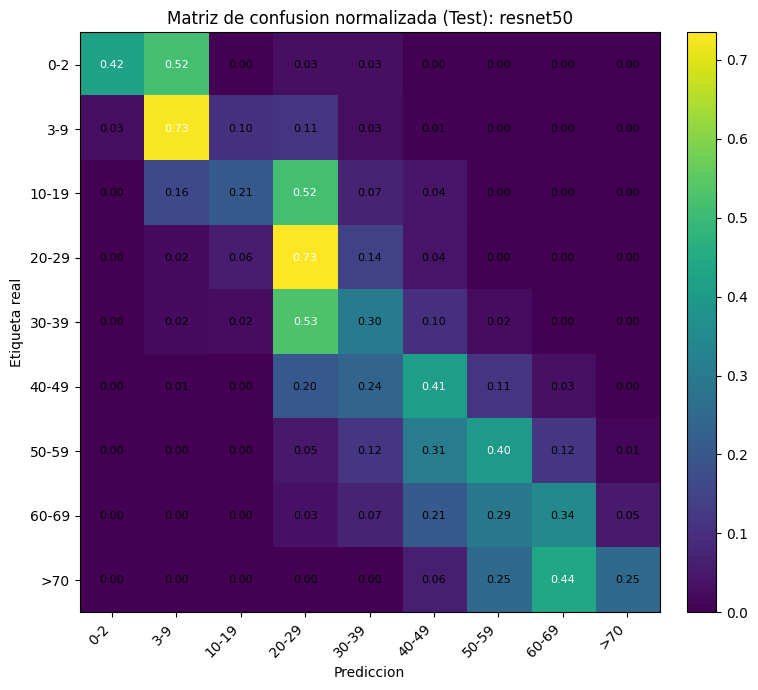

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt



num_classes = 9
class_labels = ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", ">70"]

cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_normalized, cmap="viridis")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"Matriz de confusion normalizada (Test): resnet50")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Etiqueta real")
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_yticklabels(class_labels)

threshold = cm_normalized.max() / 2 if cm_normalized.size else 0
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(
            j, i, f"{cm_normalized[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm_normalized[i, j] > threshold else "black",
            fontsize=8
        )

plt.tight_layout()
plt.show()